### Cual es el punto con mas Mediciones de Chl-A?

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
gdf = gpd.read_file("../../export/joins/gems_chla.geojson")

In [3]:
gdf.head()

,estacion,Decision,param,fecha,value,unit,depth,granularidad,geometry
0,URY00006,si,Chl-a,2018-11-12 23:20:00,0.0000,mg/l,0.3,DIA,POINT (-55.3727 -34.5071)
1,URY00008,dudoso,Chl-a,2018-11-12 08:30:00,0.0000,mg/l,0.3,DIA,POINT (-55.2061 -34.4204)
2,URY00029,si,Chl-a,2015-11-18 11:53:00,0.0030,mg/l,0.3,DIA,POINT (-56.2355 -34.15748)
3,URY00029,si,Chl-a,2016-01-20 11:20:00,0.0036,mg/l,0.3,DIA,POINT (-56.2355 -34.15748)
4,URY00029,si,Chl-a,2016-10-12 11:10:00,0.0015,mg/l,0.3,DIA,POINT (-56.2355 -34.15748)


In [4]:
mediciones = gdf.groupby("estacion").count()["param"].reset_index(name="cantidad")
mediciones.head()

,estacion,cantidad
0,URY00006,1
1,URY00008,1
2,URY00029,20
3,URY00031,20
4,URY00032,13


In [5]:
mediciones["cantidad"].max()

np.int64(299)

In [6]:
best_estacion_id = mediciones.iloc[mediciones["cantidad"].argmax()]["estacion"]
best_estacion_id

'URY00076'

In [7]:
gdf[gdf["estacion"] == best_estacion_id]["fecha"].min()

Timestamp('2015-01-02 00:00:00')

In [8]:
gdf[gdf["estacion"] == best_estacion_id]["fecha"].max()

Timestamp('2023-04-03 06:00:00')

In [9]:
gdf[gdf["estacion"] == best_estacion_id].explore(
    tiles="Esri.WorldImagery",
    marker_kwds={"radius": 8},
    color="red",
    zoom_start=13,
)

### Serie

In [10]:
df = gdf.drop(columns=["geometry"])
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.set_index("fecha")
df = df.sort_index()

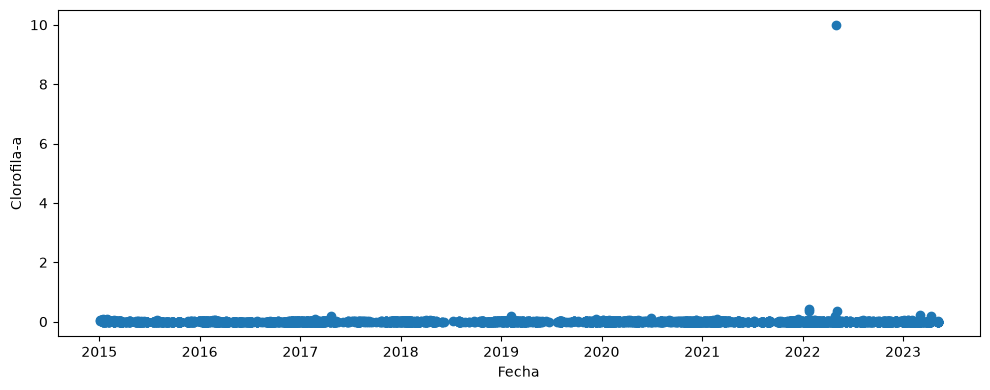

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(df.index, df["value"], marker="o")
ax.set_ylabel("Clorofila-a")
ax.set_xlabel("Fecha")
plt.tight_layout()
plt.show()

/home/enzotrindade/ProyectoAA/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


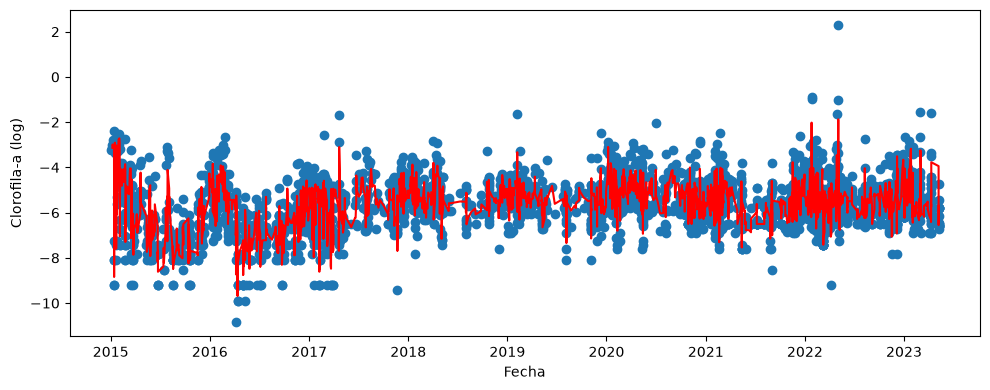

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(df.index, np.log(df["value"]), marker="o")
ax.plot(df.index, np.log(df["value"]).rolling(window=3).mean(), c="r")
ax.set_ylabel("Clorofila-a (log)")
ax.set_xlabel("Fecha")
plt.tight_layout()
plt.show()

In [13]:
df["value"].min(), df["value"].max(), df["value"].mean()

(np.float64(0.0), np.float64(10.0), np.float64(0.009118513973330106))

In [14]:
mediciones.head()

,estacion,cantidad
0,URY00006,1
1,URY00008,1
2,URY00029,20
3,URY00031,20
4,URY00032,13


In [24]:
#mediciones_sorted = mediciones.sort_values(by="cantidad")
#plt.bar(mediciones_sorted["estacion"], mediciones_sorted["cantidad"])
#plt.show()